In [2]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [3]:
# USER TABLE EXAMPLE
user_array = np.array([
    [4, 3.8, 0.5, 276],
    [3, 2.8, 0.5, 831],
    [2, 1.8, 0.5, 137]
])

user_table_raw = pd.DataFrame(user_array, columns=['pipe_outer_diameter', 'pipe_inner_diameter', 'insulation_thickness', 'segment_length'])

# PROPERTIES TABLE EXAMPLE
properties_table = pd.Series([188.6, 68, 60, 9.7, 0.025, 190, 60, 1, 1], index=['inlet_temperature', 'ambient_temperature', 'h_fluid_to_pipe', 'k_pipe', 'k_insulation', 'volumetric_flow_rate', 'density', 'specific_heat_capacity', 'emissivity'])

In [4]:
user_table_raw

,pipe_outer_diameter,pipe_inner_diameter,insulation_thickness,segment_length
0,4.0,3.8,0.5,276.0
1,3.0,2.8,0.5,831.0
2,2.0,1.8,0.5,137.0


In [5]:
class Air:

    def __init__(
        self,
        outer_diameter,
        insulation_thickness,
        ambient_temperature,
        emissivity
    ):

        self.total_diameter = outer_diameter + 2 * insulation_thickness
        self.ambient_temperature = ambient_temperature
        self.emissivity = emissivity
        

    def cp(
        self,
        ref_temperature
    ):

        '''
        Calculate specific heat capacity of air at reference temperature, which is film temperature of air around piping.
        Model is taken from Cengel, and is fitted to a range 273K - 1800K. Below 273K cp is equal to cp at 273K and above 
        1800K cp is equal to cp at 1800K.
    
        Parameters
        ----------
        ref_temperature: float, array_like
            Reference temperature at insulation-air interface [K]
    
        Returns
        -------
        _cp: float, array_like
            Specific heat capacity [kJ/kg.K]
        '''        
        
        # all constants here come from "Thermodynamics: An Engineering Approach" by Y. Cengel
        _cp_f = lambda ref_temperature: (28.11 + 0.1967e-2 * ref_temperature + 0.4802e-5 * ref_temperature ** 2 - 1.966e-9 * ref_temperature ** 3) / 28.96
        
        # going with np.array below assures that even when ref_temp is int all calculations carry on
        _cp = np.array(_cp_f(ref_temperature))
        _cp[ref_temperature < 273] = _cp_f(273)
        _cp[ref_temperature > 1800] = _cp_f(1800)
        return _cp

    def u(
        self,
        ref_temperature
    ):
    
        '''
        Calculate kinematic viscosity of air at reference temperature, which is film temperature of air around piping.
    
        Parameters
        ----------
        ref_temperature: float, array_like
            Reference temperature at insulation-air interface [K]
    
        Returns
        -------
        _u: float, array_like
            Kinematic viscosity [Pa*s]
        '''
    
        # Sutherland's Law
        _u = 1.458e-6 * ref_temperature ** 1.5 / (ref_temperature + 110.4)
        return _u
    
    def Ra(
        self,
        ambient_temperature,
        surface_temperature,
    ):
    
        '''
        Calculate Rayleigh number of air at film temperature for horizontal cylindrical body. 
        It is assummed that Pr=0.72 for air in all temperature range.
    
        Parameters
        ----------
        surface_temperature: float, array_like
            Insulation surface temperature [K]
        ambient_temperature: float
            Ambient temperature around piping [K]
    
        Returns
        -------
        _Ra: float, array_like
            Rayleigh number.
        '''

        film_temperature = (surface_temperature + ambient_temperature) / 2
    
        # Pr = 0.72 -> mean value for air on range from 220K to 2200K
        # g = 9.81 -> gravitational acceleration
        # P / R = 101.325 / 0.287 -> atmospheric pressure over gas constant for air
        # 0.0254 -> conversion from inch to meter
        _Ra = 0.72 * 9.81 * (101.325 / 0.287) ** 2 *\
            np.abs(surface_temperature - ambient_temperature) / (film_temperature ** 3 * self.u(film_temperature) ** 2) *\
            (self.total_diameter * 0.0254) ** 3
        
        return _Ra
    
    def h_combined(
        self,
        surface_temperature
    ):
    
        '''
        Calculate combined heat transfer coefficient at insulation-air interface.
        Radiation heat transfer coeff. is in its typical form.
        Convective heat transfer is based on Churchill and Chu correlation formula.
    
        Parameters
        ----------
        surface_temperature: float, array_like
            Insulation surface temperature [F]
    
        Returns
        -------
        _h_comb_vec: array_like
            Array with heat transfer coefficients of radiative and convective effects.
        '''
    
        surface_temperature_R = surface_temperature + 459.67
        ambient_temperature_R = self.ambient_temperature + 459.67
    
        # 1.71E-9 -> Stefan-Boltzmann constant
        h_rad = self.emissivity * 1.71E-9 *\
                (surface_temperature_R ** 2 + ambient_temperature_R ** 2) *\
                (surface_temperature_R + ambient_temperature_R)
    
        surface_temperature_K = surface_temperature_R * 5/9
        ambient_temperature_K = ambient_temperature_R * 5/9
        film_temperature_K = (surface_temperature_K + ambient_temperature_K) / 2
    
        # 0.1762280394 -> conversion from W/m.K to BTU/ft.h.F
        # 1000 -> conversion from kW to W
        # Pr = 0.72 -> mean value for air on range from 220K to 2200K
        # 0.6 + 0.387 / 1.20326 -> constants from Churchill and Chu correlation assuming Pr=0.72
        # 0.0254 -> conversion from inch to meters
        h_conv = 0.1762280394 * 1000 / 0.72 *\
                 (0.6 + 0.387 / 1.20326 * self.Ra(surface_temperature_K, ambient_temperature_K) ** (1/6)) ** 2 *\
                 self.u(film_temperature_K) * self.cp(film_temperature_K) / (self.total_diameter * 0.0254)
    
        _h_comb_vec = np.c_[h_rad, h_conv]
    
        return _h_comb_vec

In [27]:
class Piping_Section:

    '''
    Describes one piping section defined by user.

    Parameters
    ----------
    outer_diameter: float
        Outer diameter [inch]
    inner_diameter: float
        Inner diameter [inch]
    insulation_thickness: float
        Insulation thickness [inch]
    segment_length: float
        Length of pipng segment [ft]
    start_length: float
        Initial cumulative length. If there is more than one segment, then start_length_i = end_segment_(i-1) [F]
    inlet_temperature: float
        Temperature at start length. If there is more than one segment, then inlet_temperature_i = final_temperature_(i-1) [F]
    ambient_temperature: float
        Ambient temperature [F]
    h_fluid_to_pipe: float
        Heat transfer coeff from fluid to wall of piping [BTU/ft2.h.F]
    k_pipe: float
        Thermal conductivity of piping material [BTU/ft.h.F]
    k_insulation: float
        Thermal conductivity of insulation material [BTU/ft.h.F]
    mass_flow_rate: float
        Mass flow rate [lbm/h]
    specific_heat_capacity: float
        Specific heat capacity of liquid [BTU/lbm.R]
    h_combined_func: function
        Function for calculating combined heat transfer coeff. Must take one argument only []
    
    Returns
    -------
    Piping_Section_class: 
        Piping section class.
    '''
    
    def __init__(
        self,
        outer_diameter,
        inner_diameter,
        insulation_thickness,
        segment_length,
        start_length,
        inlet_temperature,
        ambient_temperature,
        h_fluid_to_pipe, 
        k_pipe, 
        k_insulation,
        density,
        volumetric_flow_rate,
        specific_heat_capacity,
        h_combined_func
    ):

        # piping geometry
        self.outer_diameter = outer_diameter
        self.inner_diameter = inner_diameter
        self.insulation_thickness = insulation_thickness
        self.segment_length = segment_length
        self.start_length = start_length
        self.total_diameter = self.outer_diameter + 2 * self.insulation_thickness
        self.end_length = self.start_length + self.segment_length
        
        # piping thermal properties
        self.h_fluid_to_pipe = h_fluid_to_pipe
        self.k_pipe = k_pipe
        self.k_insulation = k_insulation

        # fluid properties
        self.inlet_temperature = inlet_temperature
        self.ambient_temperature = ambient_temperature
        self.density = density
        self.volumetric_flow_rate = volumetric_flow_rate
        self.specific_heat_capacity = specific_heat_capacity
        
        # 1LPM = 0.0353147 ft3/min * 60 min / 1 h
        self.mass_flow_rate = self.density * self.volumetric_flow_rate * 0.0353147 * 60 # lbm/h

        # add heat rate per segment length, that will be populated during solution for total piping
        self.heat_rate_psl_total = 0
        self.heat_rate_psl_surface = 0 

        # heat transfer coefficient functoin
        self.h_comb = h_combined_func

    def K(
        self,
        h_combined
    ):
    
        '''
        Calculate combined thermal conductivity.
    
        Parameters
        ----------
        h_combined: float, array_like
            Combined surface heat transfer coeff (convection + radiation effect) [BTU/ft2.h.F]
    
        Returns
        -------
        _K: float, array_like
            Combined thermal conductivity [BTU/ft.h.F]
        '''

        _R = (12 * 2) / (self.h_fluid_to_pipe * self.inner_diameter) +\
             np.log( self.outer_diameter / self.inner_diameter ) / self.k_pipe +\
             np.log( self.total_diameter / self.outer_diameter ) / self.k_insulation +\
             (12 * 2) / (h_combined * self.total_diameter)
    
        self.K_combined = 1 / _R

        return self.K_combined

    def T(
        self,
        length, 
        h_combined
    ):
    
        '''
        Calculate fluid temperature at provided length and combined heat transfer coefficient.
        Given already specified by user piping geometry.
    
        Parameters
        ----------
        length: float, array_like
            Length at which temperature is to be calculated [ft]
        h_combined_surface: float, array_like
            Combined heat transfer coefficient at the insulation-air interface [BTU/ft2.h.F]
    
        Returns
        -------
        T_at_length: float, array_like
            Temperature calculated at provided length [F]
        '''
    
        exponential_part = np.exp(
            -2 * np.pi * self.K(h_combined) * length / ( self.mass_flow_rate * self.specific_heat_capacity )
        )
    
        T_at_length = self.ambient_temperature + ( self.inlet_temperature - self.ambient_temperature ) * exponential_part
    
        self.fluid_temperature = T_at_length

        return self.fluid_temperature

    def calculate_heat_per_length(self, k, T_2=None, T_1=None, LMTD=None):
        if LMTD == None:
            _hpl = 2 * np.pi * k * (T_2 - T_1)
        else:
            _hpl = 2 * np.pi * k * LMTD
        
        return _hpl
    
    def loss_function(self, surface_temperature, length=None):
        h_comb = self.h_comb(surface_temperature).sum(1)
        self.T(length, h_comb)
        loss = (
            self.calculate_heat_per_length(self.K(10000), self.fluid_temperature, surface_temperature) -\
            self.calculate_heat_per_length(self.K(h_comb), self.fluid_temperature, self.ambient_temperature)
        ) ** 2        
        return loss

    def find_surface_temp(self, length):

        self.minim = minimize(
            self.loss_function,
            (self.inlet_temperature + self.ambient_temperature) / 2,
            args=(length)
        )

        return self.minim.x

    def temperature_profile(self, n=2, mode='exact'):

        temp_profile = []
        surf_temp_profile = []
        h_comb_profile = []
        segment_length = []
        for _l in np.linspace(0, self.segment_length, n):

            if mode.lower() == 'exact':
                _T_surf_l = self.find_surface_temp(_l)
                _h_comb_vec_l = self.h_comb(_T_surf_l).flatten()
            elif mode.lower() == 'conservative':
                _T_surf_l = self.ambient_temperature
                _h_comb_vec_l = 10000 * np.ones(2)
            
            _T_l = self.T(_l, _h_comb_vec_l.sum())

            temp_profile.append(_T_l)
            surf_temp_profile.append(_T_surf_l)
            h_comb_profile.append(_h_comb_vec_l)
            segment_length.append(_l)

        _result_df = pd.DataFrame(
            np.c_[segment_length, temp_profile, surf_temp_profile, h_comb_profile],
            columns=["length", "temp", "surf_temp", "h_rad", "h_conv"]
        )

        self.temp_prof = _result_df

        return self.temp_prof

In [26]:
def LMTD(T_i, T_e, T_a):
    # use np.abs for cases when fluid temperature is less than ambient temperature
    return ( T_i - T_e ) / ( np.log(np.abs(T_i - T_a)) - np.log(np.abs(T_e - T_a)) )

In [8]:
def calculate_total_piping(piping_class, air_surface_class, user_table, properties_table, n=2, mode='exact'):
 
    class_list = []

    for i in range(0, user_table.shape[0]):

        # load air class
        a = air_surface_class(*user_table_raw.loc[i, ['pipe_outer_diameter', 'insulation_thickness']], *properties_table[['ambient_temperature', 'emissivity']])
        
        # load piping class
        if i == 0:
            ps = piping_class(*user_table.loc[0, :], 0, *properties_table[:-1], a.h_combined)
        else:
            ps = piping_class(*user_table.loc[i, :], ps.end_length, ps.temp_prof.loc[n-1, 'temp'], *properties_table[1:-1], a.h_combined)

        # find temperature profile
        ps.temperature_profile(n=n, mode=mode)

        # load heat rates
        # load heat transfer rate per segment length from fluid to air
        ps.heat_rate_psl_total = ps.calculate_heat_per_length(
            ps.K_combined, 
            LMTD=LMTD(
                *ps.temp_prof['temp'][[0, n-1]], 
                ps.ambient_temperature
            )
        )
        
        # load heat transfer rate per segment length from surface to air
        ps.heat_rate_psl_surface = ps.calculate_heat_per_length(
            (ps.temp_prof.loc[n-1, 'surf_temp'] - ps.ambient_temperature) / (ps.temp_prof.loc[n-1, 'temp'] - ps.ambient_temperature) \
            * ps.temp_prof.loc[n-1, ['h_rad', 'h_conv']] * ps.total_diameter / 24, 
            LMTD=LMTD(
                *ps.temp_prof['temp'][[0, n-1]], 
                ps.ambient_temperature
            )
        )

        # append the list
        class_list.append(ps)
    
    return class_list

In [9]:
def final_table(piping_section_list):

    # make sure n=2
    assert(piping_section_list[0].temp_prof.shape[0] == 2), print('Number of points must be n=2')
    
    _final_table = pd.DataFrame(
        index=np.arange(0, len(piping_section_list)),
        columns=[
            'segment_length',
            'temperature_inlet',
            'temperature_outlet',
            'surface_temperature_inlet',
            'surface_temperature_outlet',
            'heat_to_ins',
            'heat_by_radiation',
            'heat_by_convection',
            'heat_sum',
            'diff'
        ],
        dtype=float
    )       
    
    for i in range(len(piping_section_list)):

        _final_table.loc[i, 'segment_length'] = piping_section_list[i].segment_length
        _final_table.loc[i, ['temperature_inlet', 'temperature_outlet']] = piping_section_list[i].temp_prof['temp'].values
        _final_table.loc[i, ['surface_temperature_inlet', 'surface_temperature_outlet']] = piping_section_list[i].temp_prof['surf_temp'].values
        _final_table.loc[i, 'heat_to_ins'] = piping_section_list[i].heat_rate_psl_total
        _final_table.loc[i, ['heat_by_radiation', 'heat_by_convection']] = piping_section_list[i].heat_rate_psl_surface.values
        _final_table.loc[i, 'heat_sum'] = _final_table.loc[i, ['heat_by_radiation', 'heat_by_convection']].sum()
        _final_table.loc[i, 'diff'] = np.abs(_final_table.loc[i, 'heat_to_ins'] - _final_table.loc[i, 'heat_sum'])

    return _final_table

In [10]:
def final_table_units_handler(piping_section_list, units):

    '''
    Converts final table to correct units.

    Parameters
    ----------
    mode: str
        Mode of calculation. Either "conservative" or "exact" []
    units: str
        Either "SI" or "Imperial" []

    Returns
    -------
    _uh_final_table: pd.DataFrame
        Final table.
    '''

    _uh_final_table = final_table(piping_section_list)

    rename_columns = lambda length, temp, heat: [
        f'Segment Length [{length}]',
        f'Temperature Inlet [{temp}]',
        f'Temperature Outlet [{temp}]',
        f'Surface Temperature Inlet [{temp}]',
        f'Surface Temperature Outlet [{temp}]',
        f'Heat Transfer to Insulation [{heat}]',
        f'Heat Transfer by Radiation [{heat}]',
        f'Heat Transfer by Convection [{heat}]',
        f'Heat Transfer Total [{heat}]',
        f'Difference [{heat}]'
    ]

    length, temp, heat = ['ft', 'F', 'BTU/h.ft']

    if units.lower() == 'si':
        length, temp, heat = ['m', 'C', 'W/m']
        _uh_final_table['segment_length'] = _uh_final_table['segment_length'] * 0.3048 # 1 ft = 0.3048 m
        _uh_final_table['temperature_inlet'] = (_uh_final_table['temperature_inlet'] - 32) / 1.8
        _uh_final_table['temperature_outlet'] = (_uh_final_table['temperature_outlet'] - 32) / 1.8
        _uh_final_table['surface_temperature_inlet'] = (_uh_final_table['surface_temperature_inlet'] - 32) / 1.8
        _uh_final_table['surface_temperature_outlet'] = (_uh_final_table['surface_temperature_outlet'] - 32) / 1.8
        _uh_final_table['heat_to_ins'] = _uh_final_table['heat_to_ins'] * 0.293071 / 0.3048 # 1 BTU/h.ft = 0.293071 / 0.3048 W/m
        _uh_final_table['heat_by_radiation'] = _uh_final_table['heat_by_radiation'] * 0.293071 / 0.3048 # 1 BTU/h.ft = 0.293071 / 0.3048 W/m
        _uh_final_table['heat_by_convection'] = _uh_final_table['heat_by_convection'] * 0.293071 / 0.3048 # 1 BTU/h.ft = 0.293071 / 0.3048 W/m
        _uh_final_table['heat_sum'] = _uh_final_table['heat_sum'] * 0.293071 / 0.3048 # 1 BTU/h.ft = 0.293071 / 0.3048 W/m
        _uh_final_table['diff'] = _uh_final_table['diff'] * 0.293071 / 0.3048 # 1 BTU/h.ft = 0.293071 / 0.3048 W/m

    _uh_final_table.columns = rename_columns(length, temp, heat)

    return _uh_final_table.round(2)

In [11]:
cl = calculate_total_piping(Piping_Section, Air, user_table_raw, properties_table)

In [12]:
final_table(cl)

,segment_length,temperature_inlet,temperature_outlet,surface_temperature_inlet,surface_temperature_outlet,heat_to_ins,heat_by_radiation,heat_by_convection,heat_sum,diff
0,276.0,188.600000,187.862906,95.516173,95.365997,64.509791,39.017276,25.480936,64.498212,0.011580
1,831.0,187.862906,186.145765,94.542805,94.202909,49.913312,29.913514,19.990786,49.904299,0.009013
2,137.0,186.145765,185.943882,92.855639,92.817674,35.595215,21.031931,14.556790,35.588721,0.006494


In [13]:
final_table_units_handler(cl, units='imperial')

,Segment Length [ft],Temperature Inlet [F],Temperature Outlet [F],Surface Temperature Inlet [F],Surface Temperature Outlet [F],Heat Transfer to Insulation [BTU/h.ft],Heat Transfer by Radiation [BTU/h.ft],Heat Transfer by Convection [BTU/h.ft],Heat Transfer Total [BTU/h.ft],Difference [BTU/h.ft]
0,276.0,188.60,187.86,95.52,95.37,64.51,39.02,25.48,64.50,0.01
1,831.0,187.86,186.15,94.54,94.20,49.91,29.91,19.99,49.90,0.01
2,137.0,186.15,185.94,92.86,92.82,35.60,21.03,14.56,35.59,0.01


In [14]:
cl[0].mass_flow_rate * cl[0].specific_heat_capacity * (cl[0].inlet_temperature - cl[0].fluid_temperature) / cl[0].segment_length

np.float64(64.5097913892073)

In [15]:
cl[0].heat_rate_psl_surface.sum()

np.float64(64.49821172626754)

In [16]:
cl[0].heat_rate_psl_total

np.float64(64.50979138921014)

In [17]:
for i in range(len(cl)):
    print(cl[i].mass_flow_rate * cl[i].specific_heat_capacity * (cl[i].inlet_temperature - cl[i].fluid_temperature) / cl[i].segment_length,
          cl[i].heat_rate_psl_surface.sum() /\
          cl[i].heat_rate_psl_total)

64.5097913892073 0.9998204975912458
49.913311638286416 0.9998194367191383
35.59521474866498 0.9998175684415768


In [18]:
cl[0].temperature_profile().values.T.flatten().round(0)

array([  0., 276., 189., 188.,  96.,  95.,   1.,   1.,   1.,   1.])

In [19]:
cl[0].temperature_profile().values.round(0)

array([[  0., 189.,  96.,   1.,   1.],
       [276., 188.,  95.,   1.,   1.]])

In [20]:
cl[0].temperature_profile().T.stack().to_frame().T.droplevel(1, 1)

,length,length,temp,temp,surf_temp,surf_temp,h_rad,h_rad,h_conv,h_conv
0,0.0,276.0,188.6,187.862906,95.516173,95.365997,1.086323,1.085863,0.710214,0.709143


In [21]:
t=2
L = np.array([np.linspace(c.start_length, c.end_length, 10) for c in cl])
T = np.array([c.temperature_profile(10).loc[:, 'temp'] for c in cl])
L_t = np.array([np.linspace(c.start_length, c.end_length, t) for c in cl])
T_t = np.array([c.temperature_profile(t).loc[:, 'temp'] for c in cl])
T_s = np.array([c.temperature_profile(t).loc[:, 'surf_temp'] for c in cl])

In [22]:
A = np.c_[L_t.flatten(), T_t.flatten(), T_s.flatten()]

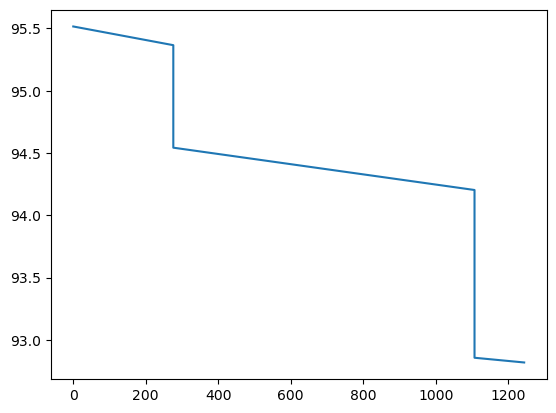

In [23]:
#plt.plot(A[:, 0], A[:, 1])
plt.plot(A[:, 0], A[:, 2])

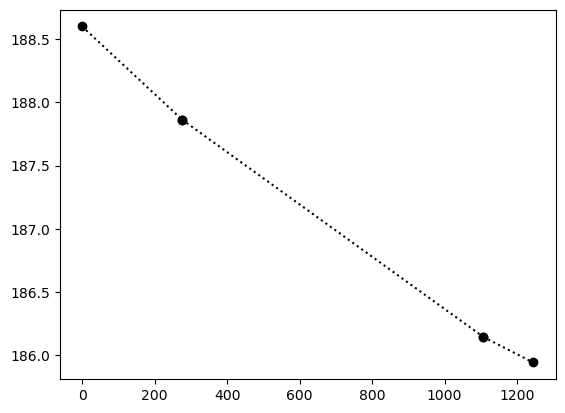

In [24]:
plt.plot(L_t.T, T_t.T, 'ok:')

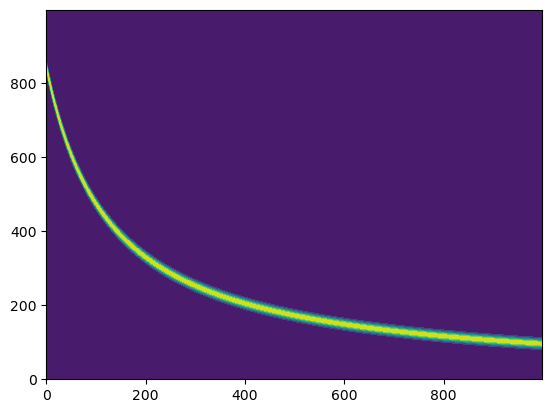

In [25]:
hh = Piping_Section(*user_table_raw.loc[0, :], 0, *properties_table[:-1], lambda x: np.linspace(0.1, 5, 1000).reshape(-1, 1))
HH = np.array([np.exp(-hh.loss_function(T_s, 100)) for T_s in np.linspace(68, 188, 1000)])
HH_1 = np.array([np.exp(-hh.loss_function(T_s, 100000)) for T_s in np.linspace(68, 188, 1000)])
plt.contourf(HH)

https://matplotlib.org/stable/gallery/mplot3d/box3d.html